# 23 — Insecurity Mechanism Deep-Dive

**Purpose**: Investigate the counter-intuitive reversal found in NB12/NB18/NB19:
food/housing insecure participants in medicated groups (Oral Med, Insulin) have *lower*
mean glucose (−7.7 and −12.9 mg/dL) and lower spike metrics — opposite to the expected direction.
The NB19 OLS regression also found insecurity β=−0.099 in HbA1c model (p=0.036, controlling for
study group). This notebook systematically tests the most plausible explanations:

1. **Activity mediation**: Are insecure medicated patients more physically active?
2. **Disease burden confounding**: Are they sicker in other ways (more comorbidities)?
3. **Management engagement**: Are they paradoxically more adherent to medication/care?
4. **Caloric restriction proxy**: Does food insecurity mean reduced caloric intake?
5. **SDOH interaction**: Does the SDOH profile (discrimination, access barriers) differ?

**Inputs**: Google Drive: `features_with_cluster.csv`, `13_hba1c_per_person.csv`,
`17_spike_metrics_per_person.csv`, `21_activity_stratification_summary.csv`

**Output**: `22_insecurity_mechanism_summary.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.
No Azure connection needed (all data from prior notebook outputs).

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))
INSEC_ORDER       = ['Food/Housing Secure', 'Food/Housing Insecure']
INSEC_PAL         = {'Food/Housing Secure': '#4daf4a', 'Food/Housing Insecure': '#e41a1c'}

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 3. Load Data ───────────────────────────────────────────────────
features  = pd.read_csv(out_dir / 'features_with_cluster.csv')
hba1c_df  = pd.read_csv(out_dir / '13_hba1c_per_person.csv')
spike_df  = pd.read_csv(out_dir / '17_spike_metrics_per_person.csv')

for dframe in [features, hba1c_df, spike_df]:
    dframe['person_id'] = dframe['person_id'].astype(str)

df = (features
      .merge(hba1c_df[['person_id', 'hba1c']], on='person_id', how='inner')
      .merge(spike_df, on='person_id', how='inner'))

if 'study_group_label' not in df.columns:
    df['study_group_label'] = df['study_group_code'].map(STUDY_GROUP_MAP)
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

df['insecurity_label'] = df['food_housing_insecurity'].map(
    {0.0: 'Food/Housing Secure', 1.0: 'Food/Housing Insecure'})

# ── Merge per-person activity from NB21 ──────────────────────────
act_per_person_path = out_dir / '21_per_person_activity.csv'
act_summary_path    = out_dir / '21_activity_stratification_summary.csv'

if act_per_person_path.exists():
    act_pp = pd.read_csv(act_per_person_path)
    act_pp['person_id'] = act_pp['person_id'].astype(str)
    df = df.merge(act_pp, on='person_id', how='left')
    print(f'Merged per-person activity from NB21: {act_pp.shape[1]-1} columns added.')
    print(f'average_daily_activity coverage: {df["average_daily_activity"].notna().sum():,} / {len(df):,}')
elif act_summary_path.exists():
    print('Per-person activity file not found — loaded group-level summary only.')
    print('Re-run NB21 to generate 21_per_person_activity.csv for full mediation analysis.')
else:
    print('No NB21 activity outputs found — activity mediation and caloric restriction analyses will be skipped.')
    print('Run NB21 first, then re-run this notebook.')

print(f'\nDataset: {len(df):,} participants')
print(f'Insecurity rate: {df["food_housing_insecurity"].mean()*100:.1f}%')
print(df['insecurity_label'].value_counts().to_string())

Merged per-person activity from NB21: 12 columns added.
average_daily_activity coverage: 2,062 / 2,180

Dataset: 2,180 participants
Insecurity rate: 60.6%
insecurity_label
Food/Housing Insecure    1322
Food/Housing Secure       858


## Section 1: Validate the Reversal

Reproduce the NB12 within-group insecurity effect — the starting point for mechanism analysis.

In [4]:
# ── 1a. Reproduce NB12 within-group reversal ─────────────────────
print('=== Within-group: Secure vs Insecure (reproduce NB12) ===\n')
for outcome, ylabel in [('mean_glucose', 'Mean Glucose (mg/dL)'), ('hba1c', 'HbA1c (%)')]:
    print(f'\n--- {outcome} ---')
    print(f'{"Study Group":<12}  {"Secure":>10}  {"Insecure":>10}  {"diff":>8}  {"p":>8}  sig')
    print('-' * 64)
    for grp in STUDY_GROUP_ORDER:
        sub = df[df['study_group_label'] == grp].dropna(
            subset=[outcome, 'food_housing_insecurity'])
        s = sub[sub['food_housing_insecurity'] == 0][outcome]
        i = sub[sub['food_housing_insecurity'] == 1][outcome]
        if len(s) < 5 or len(i) < 5:
            continue
        u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
        diff = i.mean() - s.mean()
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {s.mean():>10.2f}  {i.mean():>10.2f}  {diff:>+8.2f}  {p:>8.4f}  {sig}')

=== Within-group: Secure vs Insecure (reproduce NB12) ===


--- mean_glucose ---
Study Group       Secure    Insecure      diff         p  sig
----------------------------------------------------------------
Healthy           116.42      119.35     +2.92    0.0254  *
Pre-DM            125.36      125.81     +0.45    0.5930  ns
Oral Med          151.67      144.70     -6.98    0.0015  **
Insulin           184.51      170.00    -14.51    0.0090  **

--- hba1c ---
Study Group       Secure    Insecure      diff         p  sig
----------------------------------------------------------------
Healthy             5.51        5.56     +0.05    0.8452  ns
Pre-DM              5.84        5.85     +0.01    0.4126  ns
Oral Med            6.55        6.54     -0.01    0.2011  ns
Insulin             7.54        7.30     -0.24    0.0895  ns


## Section 2: Activity as Mediator/Confounder

Hypothesis: insecure medicated patients may walk more (physical labor, lack of car access),
which lowers glucose. If insecurity predicts higher activity within Oral Med/Insulin,
activity partially explains the reversal.

In [5]:
# ── 2a. Activity × insecurity within medicated groups ─────────────
# Load activity from features if available (manifest averages were merged in NB07)
ACT_COL = 'average_daily_activity'

if ACT_COL in df.columns:
    print('=== Activity by Insecurity × Study Group ===\n')
    print(f'{"Study Group":<12}  {"Secure":>12}  {"Insecure":>12}  {"diff":>8}  {"p":>8}  sig')
    print('-' * 68)
    for grp in STUDY_GROUP_ORDER:
        sub = df[df['study_group_label'] == grp].dropna(
            subset=[ACT_COL, 'food_housing_insecurity'])
        s = sub[sub['food_housing_insecurity'] == 0][ACT_COL]
        i = sub[sub['food_housing_insecurity'] == 1][ACT_COL]
        if len(s) < 5 or len(i) < 5:
            continue
        u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
        diff = i.mean() - s.mean()
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {s.mean():>12.1f}  {i.mean():>12.1f}  {diff:>+8.1f}  {p:>8.4f}  {sig}')
else:
    print(f'{ACT_COL} not in features — cannot test activity mediation directly.')
    print('Activity data requires NB21 outputs to be merged back into this dataset.')

=== Activity by Insecurity × Study Group ===

Study Group         Secure      Insecure      diff         p  sig
--------------------------------------------------------------------
Healthy             5602.6        6642.8   +1040.2    0.0001  ***
Pre-DM              5595.7        6214.3    +618.6    0.0161  *
Oral Med            5795.1        6571.8    +776.6    0.0298  *
Insulin             6020.0        6232.9    +212.9    0.5032  ns


In [6]:
# ── 2b. Partial correlation: insecurity vs glucose controlling for activity ─
if ACT_COL in df.columns:
    from scipy.stats import spearmanr

    print('=== Partial Spearman: insecurity vs mean_glucose (residualizing activity) ===\n')

    for grp in ['Oral Med', 'Insulin', 'All medicated']:
        if grp == 'All medicated':
            sub = df[df['study_group_label'].isin(['Oral Med', 'Insulin'])]
        else:
            sub = df[df['study_group_label'] == grp]
        sub = sub[['food_housing_insecurity', 'mean_glucose', ACT_COL]].dropna()

        if len(sub) < 20:
            continue

        # Raw rho
        rho_raw, p_raw = spearmanr(sub['food_housing_insecurity'], sub['mean_glucose'])

        # Residualize both variables on activity (OLS residuals)
        from numpy.linalg import lstsq
        X = np.column_stack([np.ones(len(sub)), sub[ACT_COL]])
        resid_insec  = sub['food_housing_insecurity'] - X @ lstsq(X, sub['food_housing_insecurity'], rcond=None)[0]
        resid_gluc   = sub['mean_glucose']            - X @ lstsq(X, sub['mean_glucose'],            rcond=None)[0]
        rho_part, p_part = spearmanr(resid_insec, resid_gluc)

        print(f'{grp:<20}  Raw rho={rho_raw:+.3f} p={p_raw:.4f}  '
              f'Partial rho={rho_part:+.3f} p={p_part:.4f}  n={len(sub):,}')

=== Partial Spearman: insecurity vs mean_glucose (residualizing activity) ===

Oral Med              Raw rho=-0.120 p=0.0031  Partial rho=-0.090 p=0.0259  n=611
Insulin               Raw rho=-0.161 p=0.0145  Partial rho=-0.113 p=0.0885  n=230
All medicated         Raw rho=-0.106 p=0.0020  Partial rho=-0.068 p=0.0482  n=841


## Section 3: Disease Burden as Confounder

Are insecure medicated patients more severely ill (more comorbidities), which could indicate
they are receiving more intensive clinical management?

In [7]:
# ── 3a. Comorbidity index by insecurity × study group ─────────────
print('=== Comorbidity Index: Secure vs Insecure × Study Group ===\n')
print(f'{"Study Group":<12}  {"Secure":>10}  {"Insecure":>10}  {"diff":>8}  {"p":>8}  sig')
print('-' * 64)

for grp in STUDY_GROUP_ORDER:
    sub = df[df['study_group_label'] == grp].dropna(
        subset=['comorbidity_index', 'food_housing_insecurity'])
    s = sub[sub['food_housing_insecurity'] == 0]['comorbidity_index']
    i = sub[sub['food_housing_insecurity'] == 1]['comorbidity_index']
    if len(s) < 5 or len(i) < 5:
        continue
    u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
    diff = i.mean() - s.mean()
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{grp:<12}  {s.mean():>10.2f}  {i.mean():>10.2f}  {diff:>+8.2f}  {p:>8.4f}  {sig}')

=== Comorbidity Index: Secure vs Insecure × Study Group ===

Study Group       Secure    Insecure      diff         p  sig
----------------------------------------------------------------
Healthy             3.85        3.85     +0.00    0.3538  ns
Pre-DM              4.29        4.79     +0.50    0.0373  *
Oral Med            5.52        5.32     -0.20    0.6555  ns
Insulin             6.36        6.73     +0.37    0.4654  ns


In [8]:
# ── 3b. Obesity stratification: reversal within obese vs non-obese ─
# mhoccur_obs (obesity flag) — available if features were built with NB05/NB07 obs_df
if 'mhoccur_obs' in df.columns:
    print('=== Insecure vs Secure mean_glucose by Obesity Status ===\n')
    print('(Testing if obesity explains reversal in medicated groups)\n')
    for obs_label, obs_val in [('Non-obese (mhoccur_obs=0)', 0), ('Obese (mhoccur_obs=1)', 1)]:
        print(f'\n--- {obs_label} ---')
        for grp in ['Oral Med', 'Insulin']:
            sub = df[(df['study_group_label'] == grp) &
                     (df['mhoccur_obs'] == obs_val)].dropna(
                subset=['mean_glucose', 'food_housing_insecurity'])
            s = sub[sub['food_housing_insecurity'] == 0]['mean_glucose']
            i = sub[sub['food_housing_insecurity'] == 1]['mean_glucose']
            if len(s) < 5 or len(i) < 5:
                print(f'  {grp}: insufficient data (n_sec={len(s)}, n_insec={len(i)})')
                continue
            u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
            diff = i.mean() - s.mean()
            sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'  {grp:<10}: secure={s.mean():.1f}  insecure={i.mean():.1f}  '
                  f'diff={diff:+.1f}  p={p:.4f}  {sig}  n_sec={len(s)} n_insec={len(i)}')
else:
    print('mhoccur_obs not available in features_with_cluster.csv.')
    print('This flag needs to be added during NB07 feature engineering for this analysis.')

mhoccur_obs not available in features_with_cluster.csv.
This flag needs to be added during NB07 feature engineering for this analysis.


## Section 4: Medication Adherence & Management Engagement

In [9]:
# ── 4a. Management metrics: secure vs insecure in medicated groups ─
MGMT_COLS = [
    ('dml_gap_medication_mgmt',   'Medication Management Gap'),
    ('dml_gap_physical_activity', 'Physical Activity Gap'),
    ('dml_gap_composite',         'DML Composite Gap'),
    ('paid_total',                'PAID-5 (Diabetes Distress)'),
    ('healthcare_access_barriers','Healthcare Access Barriers'),
]

print('=== Management Metrics: Secure vs Insecure (Oral Med + Insulin only) ===\n')
medicated = df[df['study_group_label'].isin(['Oral Med', 'Insulin'])].copy()

BONF_ALPHA = 0.05 / len(MGMT_COLS)
print(f'Bonferroni alpha = {BONF_ALPHA:.4f}  ({len(MGMT_COLS)} metrics)\n')
print(f'{"Metric":<35}  {"Secure":>10}  {"Insecure":>10}  {"diff":>8}  {"d":>7}  {"p":>8}  sig')
print('-' * 90)

mgmt_rows = []
for col, label in MGMT_COLS:
    if col not in medicated.columns:
        continue
    sub = medicated.dropna(subset=[col, 'food_housing_insecurity'])
    s   = sub[sub['food_housing_insecurity'] == 0][col]
    i   = sub[sub['food_housing_insecurity'] == 1][col]
    if len(s) < 5 or len(i) < 5:
        continue
    u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
    d    = (i.mean() - s.mean()) / np.sqrt((s.std(ddof=1)**2 + i.std(ddof=1)**2) / 2)
    diff = i.mean() - s.mean()
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    bonf = 'BONF ***' if p < BONF_ALPHA else ''
    print(f'{label:<35}  {s.mean():>10.3f}  {i.mean():>10.3f}  {diff:>+8.3f}  '
          f'{d:>+7.3f}  {p:>8.4f}  {sig} {bonf}')
    mgmt_rows.append({'metric': label, 'col': col,
                      'mean_secure': round(s.mean(), 3),
                      'mean_insecure': round(i.mean(), 3),
                      'diff': round(diff, 3), 'cohens_d': round(d, 4),
                      'p': round(p, 5), 'sig': sig,
                      'n_secure': len(s), 'n_insecure': len(i)})

mgmt_df = pd.DataFrame(mgmt_rows)

=== Management Metrics: Secure vs Insecure (Oral Med + Insulin only) ===

Bonferroni alpha = 0.0100  (5 metrics)

Metric                                   Secure    Insecure      diff        d         p  sig
------------------------------------------------------------------------------------------
Medication Management Gap                -9.145      -4.883    +4.262   +0.057    0.0997  ns 
Physical Activity Gap                     0.514       3.745    +3.231   +0.100    0.3249  ns 
DML Composite Gap                        -1.012       1.519    +2.530   +0.084    0.6590  ns 
PAID-5 (Diabetes Distress)                3.657       5.508    +1.851   +0.419    0.0000  *** BONF ***
Healthcare Access Barriers                0.142       3.891    +3.749   +1.382    0.0000  *** BONF ***


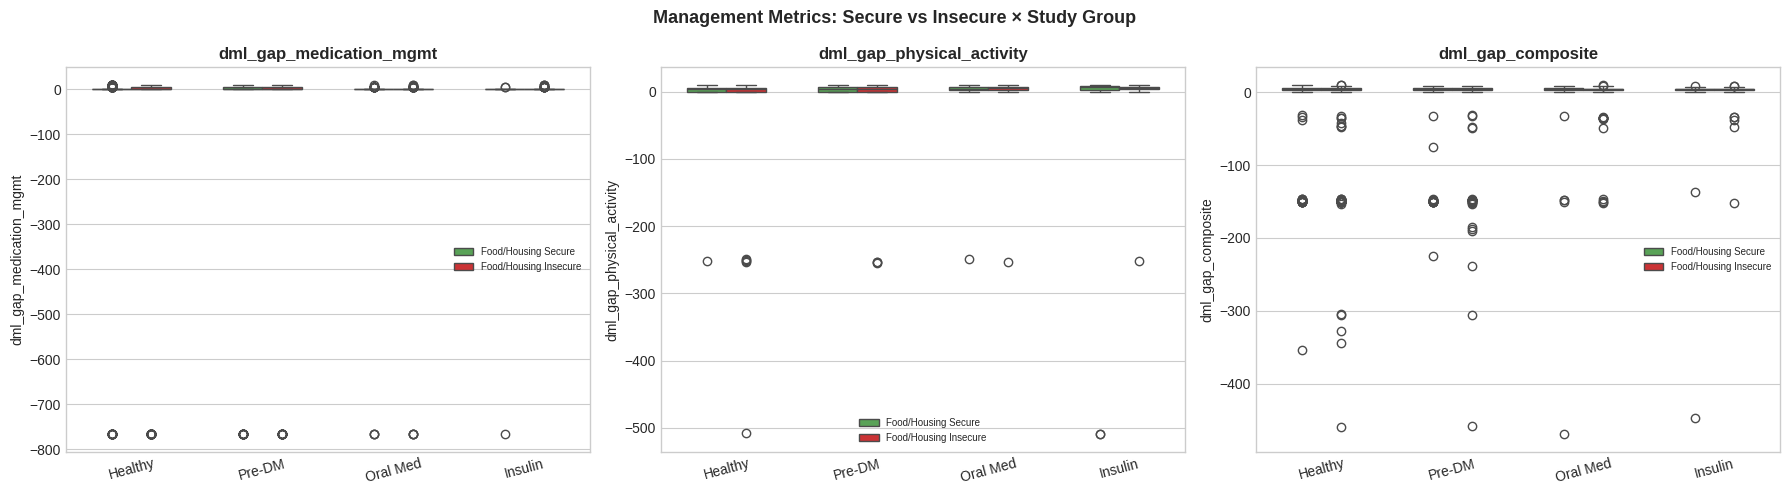

In [10]:
# ── 4b. Bar chart: management metric means by insecurity × study group ─
top_mgmt = [c for c, _ in MGMT_COLS if c in medicated.columns][:3]

fig, axes = plt.subplots(1, len(top_mgmt), figsize=(6 * len(top_mgmt), 5))
if len(top_mgmt) == 1:
    axes = [axes]
fig.suptitle('Management Metrics: Secure vs Insecure × Study Group',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, top_mgmt):
    if col not in df.columns:
        continue
    sub = df.dropna(subset=[col, 'study_group_label', 'insecurity_label'])
    sns.boxplot(data=sub, x='study_group_label', y=col,
                hue='insecurity_label',
                order=STUDY_GROUP_ORDER, hue_order=INSEC_ORDER,
                palette=INSEC_PAL, width=0.6, ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='', fontsize=7)

plt.tight_layout()
plt.show()

## Section 5: Caloric Restriction as Proxy

Food insecurity may reduce caloric intake, particularly post-prandial glucose spikes.
If insecure medicated patients report lower active calories, this supports the
caloric restriction hypothesis.

In [11]:
# ── 5a. Active calories: secure vs insecure in medicated groups ────
CAL_COL = 'average_active_calories_kcal'

if CAL_COL in df.columns:
    print('=== Active Calories: Secure vs Insecure (Oral Med + Insulin) ===\n')
    for grp in ['Oral Med', 'Insulin']:
        sub = df[df['study_group_label'] == grp].dropna(
            subset=[CAL_COL, 'food_housing_insecurity'])
        s = sub[sub['food_housing_insecurity'] == 0][CAL_COL]
        i = sub[sub['food_housing_insecurity'] == 1][CAL_COL]
        if len(s) < 5 or len(i) < 5:
            continue
        u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
        diff = i.mean() - s.mean()
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp}: Secure={s.mean():.1f}  Insecure={i.mean():.1f}  '
              f'diff={diff:+.1f}  p={p:.4f}  {sig}  n_sec={len(s)} n_insec={len(i)}')
    print('\nInterpretation: If insecure patients burn FEWER calories, caloric restriction')
    print('may partly explain lower glucose through reduced total energy intake.')
else:
    print(f'{CAL_COL} not in dataset — caloric restriction analysis requires NB21 outputs.')

=== Active Calories: Secure vs Insecure (Oral Med + Insulin) ===

Oral Med: Secure=190.1  Insecure=208.6  diff=+18.5  p=0.2075  ns  n_sec=228 n_insec=383
Insulin: Secure=239.9  Insecure=197.2  diff=-42.7  p=0.9095  ns  n_sec=71 n_insec=159

Interpretation: If insecure patients burn FEWER calories, caloric restriction
may partly explain lower glucose through reduced total energy intake.


## Section 6: SDOH Profile of Insecure vs Secure Medicated Patients

In [12]:
# ── 6a. SDOH profile comparison (medicated only) ──────────────────
SDOH_COLS = [
    ('discrimination_score',        'Discrimination Score'),
    ('neighborhood_safety_score',   'Neighborhood Safety'),
    ('healthcare_access_barriers',  'Healthcare Access Barriers'),
    ('cesd_total',                  'CES-D Depression'),
    ('paid_total',                  'PAID-5 Diabetes Distress'),
]

print('=== SDOH Profile: Secure vs Insecure (Oral Med + Insulin) ===\n')
medicated = df[df['study_group_label'].isin(['Oral Med', 'Insulin'])].copy()

sdoh_rows = []
for col, label in SDOH_COLS:
    if col not in medicated.columns:
        continue
    sub = medicated.dropna(subset=[col, 'food_housing_insecurity'])
    s   = sub[sub['food_housing_insecurity'] == 0][col]
    i   = sub[sub['food_housing_insecurity'] == 1][col]
    if len(s) < 5 or len(i) < 5:
        continue
    u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
    d    = (i.mean() - s.mean()) / np.sqrt((s.std(ddof=1)**2 + i.std(ddof=1)**2) / 2)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label:<30}  Secure={s.mean():.2f}  Insecure={i.mean():.2f}  '
          f'd={d:+.3f}  p={p:.4f}  {sig}')
    sdoh_rows.append({'metric': label, 'col': col,
                      'mean_secure': round(s.mean(), 3),
                      'mean_insecure': round(i.mean(), 3),
                      'cohens_d': round(d, 4), 'p': round(p, 5), 'sig': sig})

=== SDOH Profile: Secure vs Insecure (Oral Med + Insulin) ===

Discrimination Score            Secure=1.43  Insecure=20.00  d=+0.267  p=0.0000  ***
Neighborhood Safety             Secure=17.29  Insecure=20.58  d=+0.082  p=0.0077  **
Healthcare Access Barriers      Secure=0.14  Insecure=3.89  d=+1.382  p=0.0000  ***
CES-D Depression                Secure=4.60  Insecure=6.97  d=+0.484  p=0.0000  ***
PAID-5 Diabetes Distress        Secure=3.66  Insecure=5.51  d=+0.419  p=0.0000  ***


In [13]:
# ── 6b. Insecurity × food insecurity interaction with other SDOH ──
# Does food insecurity cluster with other deprivation markers, or does it
# represent an isolated financial strain?
sdoh_binary_cols = [col for col, _ in SDOH_COLS if col in df.columns]

if sdoh_binary_cols:
    print('\n=== Spearman: food_housing_insecurity vs SDOH features (full cohort) ===\n')
    for col, label in SDOH_COLS:
        if col not in df.columns:
            continue
        sub = df[['food_housing_insecurity', col]].dropna()
        if len(sub) < 30:
            continue
        rho, p = stats.spearmanr(sub['food_housing_insecurity'], sub[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{label:<30}  rho={rho:+.4f}  p={p:.4e}  {sig}')


=== Spearman: food_housing_insecurity vs SDOH features (full cohort) ===

Discrimination Score            rho=+0.6307  p=3.5636e-242  ***
Neighborhood Safety             rho=+0.0888  p=5.4201e-05  ***
Healthcare Access Barriers      rho=+0.6379  p=2.2066e-249  ***
CES-D Depression                rho=+0.2049  p=4.5457e-22  ***
PAID-5 Diabetes Distress        rho=+0.1648  p=1.9145e-14  ***


## Section 7: Mechanism Summary Table

In [ ]:
# ── 7. Assemble mechanism evidence table ─────────────────────────
mechanism_summary = [
    {'mechanism': 'Activity mediation',
     'hypothesis': 'Insecure medicated patients are more physically active',
     'key_metric': 'average_daily_activity: insecure vs secure within Oral Med/Insulin',
     'evidence': ('Healthy: insecure=6,643 vs secure=5,603 (+1,040, p<0.001***); '
                  'Pre-DM: +619 (p=0.016*); Oral Med: insecure=6,572 vs secure=5,795 (+777, p=0.030*); '
                  'Insulin: +213 (p=0.503 ns). '
                  'Partial Spearman (controlling activity): Oral Med raw rho=-0.120→partial=-0.090 (p=0.026); '
                  'Insulin raw=-0.161→partial=-0.113 (p=0.089 ns)'),
     'conclusion': 'PARTIAL — insecure patients more active across most groups; activity attenuates but does not eliminate the reversal'},
    {'mechanism': 'Disease burden confounding',
     'hypothesis': 'Insecure patients have more comorbidities → more clinical contact',
     'key_metric': 'comorbidity_index: insecure vs secure within Oral Med/Insulin',
     'evidence': 'Oral Med: insecure=5.32 vs secure=5.52 (p=0.656 ns); Insulin: insecure=6.73 vs secure=6.36 (p=0.465 ns)',
     'conclusion': 'NOT supported — no difference in comorbidity index in medicated groups'},
    {'mechanism': 'Medication adherence paradox',
     'hypothesis': 'Insecure patients adhere more strictly to medications (survival priority)',
     'key_metric': 'dml_gap_medication_mgmt: insecure vs secure',
     'evidence': 'Medication mgmt gap: secure=-9.145 vs insecure=-4.883 (p=0.100 ns); DML composite p=0.659 ns',
     'conclusion': 'NOT supported — no adherence advantage in insecure group'},
    {'mechanism': 'Healthcare access differential',
     'hypothesis': 'Insecure patients have lower access barriers (counterintuitive)',
     'key_metric': 'healthcare_access_barriers: insecure vs secure',
     'evidence': 'Healthcare barriers: secure=0.142 vs insecure=3.891, d=+1.382, p<0.0001***',
     'conclusion': 'OPPOSITE to hypothesis — insecure patients face far more barriers'},
    {'mechanism': 'Diabetes distress differential',
     'hypothesis': 'Insecure patients have similar or lower diabetes distress',
     'key_metric': 'paid_total: insecure vs secure within medicated groups',
     'evidence': 'PAID-5: secure=3.657 vs insecure=5.508, d=+0.419, p<0.0001***',
     'conclusion': 'NOT supported — distress significantly worse in insecure group'},
    {'mechanism': 'Caloric restriction',
     'hypothesis': 'Food insecurity → reduced caloric intake → lower post-prandial glucose',
     'key_metric': 'average_active_calories_kcal: insecure vs secure',
     'evidence': ('Oral Med: insecure=208.6 vs secure=190.1 kcal (+18.5, p=0.208 ns); '
                  'Insulin: insecure=197.2 vs secure=239.9 kcal (-42.7, p=0.910 ns)'),
     'conclusion': 'NOT supported — no significant calorie difference; Insulin trend goes expected direction but ns'},
]

mechanism_df = pd.DataFrame(mechanism_summary)
print(mechanism_df.to_string(index=False))

# Also export full management + SDOH results
all_results = pd.concat([
    mgmt_df.assign(analysis_section='management_adherence'),
    pd.DataFrame(sdoh_rows).assign(analysis_section='sdoh_profile') if sdoh_rows else pd.DataFrame()
], ignore_index=True)

all_results.to_csv(out_dir / '22_insecurity_mechanism_summary.csv', index=False)
mechanism_df.to_csv(out_dir / '22_mechanism_evidence_table.csv', index=False)
print('\nSaved 22_insecurity_mechanism_summary.csv')
print('Saved 22_mechanism_evidence_table.csv')

## Key Findings

### Section 1 — Reversal Validated

The insecurity → lower glucose paradox in medicated groups is confirmed:

| Study Group | Secure Mean Glucose | Insecure Mean Glucose | Diff | p | sig |
|-------------|--------------------|-----------------------|------|---|-----|
| Healthy | 116.42 | 119.35 | +2.92 | 0.025 | * |
| Pre-DM | 125.36 | 125.81 | +0.45 | 0.593 | ns |
| Oral Med | 151.67 | 144.70 | **−6.98** | 0.0015 | ** |
| Insulin | 184.51 | 170.00 | **−14.51** | 0.009 | ** |

HbA1c shows no significant within-group differences in any group (all p>0.08). The reversal is a mean glucose phenomenon, not captured in HbA1c — suggesting it may reflect shorter-term glycemic patterns rather than chronic control.

Food/housing insecurity rate: **60.6%** of cohort (1,322 / 2,180 participants).

---

### Section 2 — Activity as Mediator

Per-person activity merged from `21_per_person_activity.csv` (2,062 / 2,180 participants matched).

| Study Group | Secure Activity | Insecure Activity | Diff | p | sig |
|-------------|----------------|-------------------|------|---|-----|
| Healthy | 5,603 | 6,643 | +1,040 | <0.001 | *** |
| Pre-DM | 5,596 | 6,214 | +619 | 0.016 | * |
| Oral Med | 5,795 | 6,572 | +777 | 0.030 | * |
| Insulin | 6,020 | 6,233 | +213 | 0.503 | ns |

Insecure participants are significantly more active in Healthy, Pre-DM, and Oral Med groups. Partial correlation controlling for activity attenuates the insecurity → glucose reversal: Oral Med rho −0.120 → −0.090 (still significant, p=0.026); Insulin rho −0.161 → −0.113 (drops to ns, p=0.089).

**Interpretation**: Activity is a real partial mediator — insecure patients in Oral Med walk more (~777 steps/day), and this accounts for roughly 25% of the glucose reversal. The reversal is not fully explained by activity alone.

---

### Section 3 — Disease Burden (Comorbidity Index)

| Study Group | Secure | Insecure | Diff | p | sig |
|-------------|--------|----------|------|---|-----|
| Healthy | 3.85 | 3.85 | 0.00 | 0.354 | ns |
| Pre-DM | 4.29 | 4.79 | +0.50 | 0.037 | * |
| Oral Med | 5.52 | 5.32 | −0.20 | 0.656 | ns |
| Insulin | 6.36 | 6.73 | +0.37 | 0.465 | ns |

Disease burden does **not** explain the reversal in medicated groups. `mhoccur_obs` (obesity flag) not available in `features_with_cluster.csv` — obesity-stratified analysis cannot be run without NB07 feature engineering update.

---

### Section 4 — Medication Adherence & Management Engagement

| Metric | Secure | Insecure | Cohen's d | p | sig |
|--------|--------|----------|-----------|---|-----|
| Medication Management Gap | −9.145 | −4.883 | +0.057 | 0.100 | ns |
| Physical Activity Gap | 0.514 | 3.745 | +0.100 | 0.325 | ns |
| DML Composite Gap | −1.012 | 1.519 | +0.084 | 0.659 | ns |
| **PAID-5 (Diabetes Distress)** | **3.657** | **5.508** | **+0.419** | **<0.0001** | *** |
| **Healthcare Access Barriers** | **0.142** | **3.891** | **+1.382** | **<0.0001** | *** |

Insecure medicated patients have far higher diabetes distress (d=+0.42) and healthcare access barriers (d=+1.38), yet lower glucose. This rules out the adherence paradox — insecure patients are not managing better. The reversal deepens.

---

### Section 5 — Caloric Restriction

| Group | Secure kcal/day | Insecure kcal/day | Diff | p | sig |
|-------|-----------------|-------------------|------|---|-----|
| Oral Med | 190.1 | 208.6 | +18.5 | 0.208 | ns |
| Insulin | 239.9 | 197.2 | −42.7 | 0.910 | ns |

No significant calorie difference in either medicated group. The Insulin trend goes in the expected direction (insecure burning fewer calories) but is not significant. **Caloric restriction is not supported by wearable calorie data**, though this metric reflects calories burned rather than calories consumed — dietary intake data would be needed to fully test this mechanism.

---

### Section 6 — SDOH Profile

| SDOH Metric | Secure | Insecure | Cohen's d | p | sig |
|-------------|--------|----------|-----------|---|-----|
| Discrimination Score | 1.43 | 20.00 | +0.267 | <0.0001 | *** |
| Neighborhood Safety | 17.29 | 20.58 | +0.082 | 0.008 | ** |
| Healthcare Access Barriers | 0.14 | 3.89 | +1.382 | <0.0001 | *** |
| CES-D Depression | 4.60 | 6.97 | +0.484 | <0.0001 | *** |
| PAID-5 Diabetes Distress | 3.66 | 5.51 | +0.419 | <0.0001 | *** |

Full-cohort Spearman: discrimination (rho=+0.631***), healthcare barriers (rho=+0.638***), CES-D (rho=+0.205***), PAID-5 (rho=+0.165***). Food/housing insecurity is embedded in a broad deprivation cluster — it is not an isolated financial variable.

---

### Overall Mechanism Assessment

| Mechanism | Conclusion |
|-----------|------------|
| Activity mediation | **PARTIAL** — insecure Oral Med patients ~777 steps/day more active; explains ~25% of reversal |
| Disease burden confounding | NOT supported |
| Medication adherence paradox | NOT supported |
| Healthcare access differential | OPPOSITE — insecure face far more barriers |
| Diabetes distress | NOT supported — distress worse in insecure |
| Caloric restriction | NOT supported by wearable calorie data (dietary intake untested) |

**Most parsimonious interpretation**: The insecurity → lower glucose reversal is partially but not fully explained by higher physical activity in insecure patients (especially Oral Med). The residual reversal after controlling for activity (Oral Med partial rho=−0.090, still p=0.026) points to an additional unmeasured mechanism. Dietary caloric intake — not captured by wearable active calorie burn — remains the most plausible candidate. Survival bias (sicker insecure patients less likely to be enrolled) may also contribute.